In [1]:
import sys
sys.path.append('C:/Users/Lenovo/Desktop/2022_E/tools/')
from datasets import tropical_dataset
from load_array import LoadArray
from mxnet import autograd,gluon,init
from animator import Animator

In [2]:
tropical_data = tropical_dataset(1000)

In [3]:
batch_size = 5
data_loader = LoadArray(tropical_data,batch_size)

In [4]:
model = gluon.nn.Sequential()
model.add(
    # gluon.nn.Dense(3),
    gluon.nn.Dense(1)

)
model.initialize(init.Normal(sigma=0.01))

In [5]:
loss_func = gluon.loss.L2Loss()
optimizer = gluon.Trainer(model.collect_params(),'sgd',{'learning_rate':0.0000001})

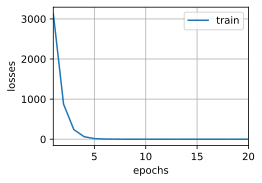

In [6]:
epochs = 20
animator = Animator(xlabel='epochs',ylabel='losses',legend=['train'],xlim=[1,20])
for epoch in range(epochs):
    for feature, label in data_loader:
            with autograd.record():
                l = loss_func(model(feature),label)
                # print(feature,model(feature))
            l.backward()
            optimizer.step(batch_size)
            temp = l.mean().item()
    animator.add(epoch+1, (temp,))
        
                

In [7]:
model[0].weight.data()

array([[0.80514044, 0.17882678, 0.03689637, 0.19232123]])

In [12]:
from mxnet import npx,np
npx.set_np()
feature = np.array([[169.44, 40.26, 10.49, 41.25]])
model(feature) # 用数据集代入测试，是为 validation of model performance

array([[151.94759]])